In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
dr=pd.read_csv('10.drug200.csv')

In [7]:
dr.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [9]:
dr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [11]:
dr.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [13]:
dr['Drug'].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [15]:
dr['Drug'].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [17]:
dr['BP'].unique()

array(['HIGH', 'LOW', 'NORMAL'], dtype=object)

In [19]:
dr.describe() #stastical analysis

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [21]:
dr.describe(include='object')

,Sex,BP,Cholesterol,Drug
count,200,200,200,200
unique,2,3,2,5
top,M,HIGH,HIGH,DrugY
freq,104,77,103,91


In [23]:
dr.duplicated().sum()

0

<Axes: xlabel='Sex', ylabel='count'>

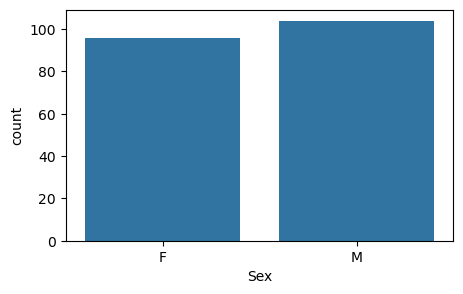

In [25]:
#eda
plt.figure(figsize=(5,3))
sns.countplot(data=dr,x='Sex')

<Axes: ylabel='count'>

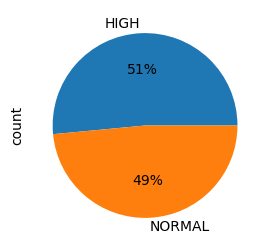

In [27]:
plt.figure(figsize=(5,3))
dr['Cholesterol'].value_counts().plot(kind='pie',autopct='%.0f%%')


<Axes: ylabel='count'>

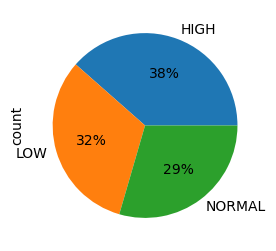

In [29]:
plt.figure(figsize=(5,3))
dr['BP'].value_counts().plot(kind='pie',autopct='%.0f%%')


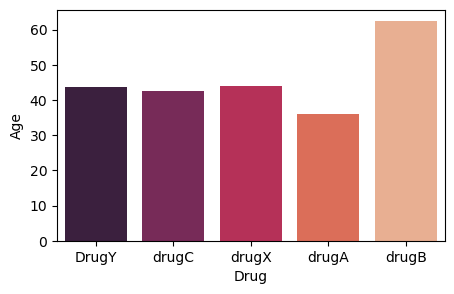

In [35]:
plt.figure(figsize=(5,3))
sns.barplot(x= dr.Drug,y=dr.Age,palette='rocket',ci=False)
plt.show()

<Axes: xlabel='Drug', ylabel='count'>

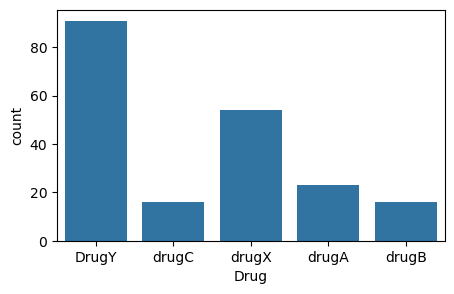

In [37]:
plt.figure(figsize=(5,3))
sns.countplot(x=dr.Drug)

In [39]:
#crosstab:to summarise categorical data and categorical data analzing relationship b/w variables
pd.crosstab(dr.Drug,dr.Sex)

Sex,F,M
Drug,,
DrugY,47,44
drugA,9,14
drugB,6,10
drugC,7,9
drugX,27,27


In [41]:
pd.crosstab(dr.BP,dr.Drug)

Drug,DrugY,drugA,drugB,drugC,drugX
BP,,,,,
HIGH,38,23,16,0,0
LOW,30,0,0,16,18
NORMAL,23,0,0,0,36


In [43]:
dr.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [45]:
dr=pd.get_dummies(dr,columns=['Sex','BP','Cholesterol'])
dr.head()

,Age,Na_to_K,Drug,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,DrugY,True,False,True,False,False,True,False
1,47,13.093,drugC,False,True,False,True,False,True,False
2,47,10.114,drugC,False,True,False,True,False,True,False
3,28,7.798,drugX,True,False,False,False,True,True,False
4,61,18.043,DrugY,True,False,False,True,False,True,False


In [47]:
dr.dtypes

Age                     int64
Na_to_K               float64
Drug                   object
Sex_F                    bool
Sex_M                    bool
BP_HIGH                  bool
BP_LOW                   bool
BP_NORMAL                bool
Cholesterol_HIGH         bool
Cholesterol_NORMAL       bool
dtype: object

In [49]:
x=dr.drop(['Drug'],axis=1)

In [51]:
y=dr['Drug']

In [53]:
x.head()

,Age,Na_to_K,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,True,False,True,False,False,True,False
1,47,13.093,False,True,False,True,False,True,False
2,47,10.114,False,True,False,True,False,True,False
3,28,7.798,True,False,False,False,True,True,False
4,61,18.043,True,False,False,True,False,True,False


In [55]:
y.head()

0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object

In [57]:
from sklearn.preprocessing import StandardScaler

In [59]:
sc=StandardScaler()

In [61]:
xs=sc.fit_transform(x)

In [63]:
from sklearn.model_selection import train_test_split


In [65]:
x_train,x_test,y_train,y_test=train_test_split(xs,y,random_state=0,test_size=0.3)

In [67]:
from sklearn.linear_model import LogisticRegression

In [69]:
m=LogisticRegression()

In [71]:
m.fit(x_train,y_train)

LogisticRegression()

In [73]:
y_pred_test=m.predict(x_test)

In [75]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [77]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

       DrugY       1.00      0.97      0.98        30
       drugA       1.00      1.00      1.00         5
       drugB       0.75      1.00      0.86         3
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        18

    accuracy                           0.98        60
   macro avg       0.95      0.99      0.97        60
weighted avg       0.99      0.98      0.98        60



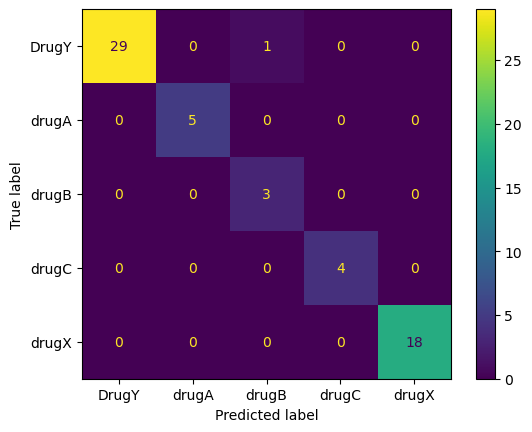

In [79]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))

In [83]:
def predict(input_data):
    input_df=pd.DataFrame([input_data],columns=['Age','Sex','BP','Cholesterol','Na_to_K'])#2
    input_df=pd.get_dummies(input_df,columns=['Sex','BP','Cholesterol'])#3
    #ensure all col are present
    for i in x.columns:# in thier any columns is missing(encoding)v alues and fill with 0 #4
        if i not in input_df:
            input_df[i]=0
    #reorder
    input_df=input_df[x.columns]#5
    scale=sc.transform(input_df)#6
    pred=m.predict(scale)#7

    return pred #
sampledata=[23,'F','HIGH','HIGH',25.355] #1
print(predict(sampledata))

['DrugY']
